# PhoBERT + SentiWordNet Baseline

## Mô tả
Hybrid model với **PhoBERT fine-tuned baseline** + Extended SentiWordNet features.

**PhoBERT Source:** `results/PhoBERT/baseline/models/phobert_model.pt` (đã fine-tune)

**Features (35 total):**
- **Original 8 features:** pos_sum, neg_sum, pos_max, neg_max, pos_mean, neg_mean, coverage, polarity
- **Statistical features (6):** pos_std, neg_std, pos_min, neg_min, pos_median, neg_median
- **Count features (4):** pos_high_count, neg_high_count, pos_word_count, neg_word_count
- **Ratio features (4):** pos_neg_ratio, pos_neg_word_ratio, pos_coverage, neg_coverage
- **Polarity features (3):** polarity_abs, sentiment_strength, net_sentiment
- **Position features (6):** first_word_pos, first_word_neg, last_word_pos, last_word_neg, pos_shift, neg_shift
- **Negation features (4):** negation_count, negation_ratio, negated_pos_sum, negated_neg_sum

**Total dimensions:** 768 (PhoBERT) + 35 (SentiWordNet) = 803 features

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers torch

In [20]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import numpy as np
print(f'CUDA: {torch.cuda.is_available()}')

CUDA: True


In [21]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
set_seed(42)

văn bản in nghiêng## 2. Config

In [22]:
class Config:
    BASE_DIR = '/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis'
    DATA_DIR = f'{BASE_DIR}/data/processed'
    MODEL_TYPE = 'PhoBERT_Sentiwordnet'
    EXPERIMENT_TYPE = 'baseline'
    RESULTS_DIR = f'{BASE_DIR}/results/{MODEL_TYPE}/{EXPERIMENT_TYPE}'
    VISUALIZATIONS_DIR = f'{RESULTS_DIR}/visualizations'
    MODELS_DIR = f'{RESULTS_DIR}/models'
    SUMMARIES_DIR = f'{RESULTS_DIR}/summaries'
    ARTIFACTS_DIR = f'{RESULTS_DIR}/artifacts'
    MODEL_NAME = 'vinai/phobert-base'
    # Path to fine-tuned PhoBERT baseline model
    PHOBERT_MODEL_DIR = f'{BASE_DIR}/results/PhoBERT/baseline/models/phobert_model.pt'
    NUM_CLASSES = 3
    LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    SENTIWORDNET_FILE = f'{BASE_DIR}/data/sentiwordnet-dataset/VietSentiWordnet_Ver1.3.5.txt'

config = Config()
print(f'Results: {config.RESULTS_DIR}')
print(f'Visualizations: {config.VISUALIZATIONS_DIR}')
print(f'Models: {config.MODELS_DIR}')
print(f'Summaries: {config.SUMMARIES_DIR}')
print(f'Artifacts: {config.ARTIFACTS_DIR}')
print(f'PhoBERT Baseline: {config.PHOBERT_MODEL_DIR}')

# ── Create directories ───────────────────────────────────────────────────────
import os
for dir_path in [config.RESULTS_DIR, config.VISUALIZATIONS_DIR,
                 config.MODELS_DIR, config.SUMMARIES_DIR, config.ARTIFACTS_DIR]:
    os.makedirs(dir_path, exist_ok=True)
print('\n✓ All directories created successfully')

Results: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet/baseline
Visualizations: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet/baseline/visualizations
Models: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet/baseline/models
Summaries: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet/baseline/summaries
Artifacts: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet/baseline/artifacts
PhoBERT Baseline: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT/baseline/models/phobert_model.pt

✓ All directories created successfully


## 3. Load Data

In [23]:
# Import from centralized data_utils module
import sys
sys.path.append(config.BASE_DIR)
from src.data_utils import load_data

train_texts, train_labels = load_data(config.DATA_DIR, 'train')
val_texts, val_labels = load_data(config.DATA_DIR, 'validation')
test_texts, test_labels = load_data(config.DATA_DIR, 'test')

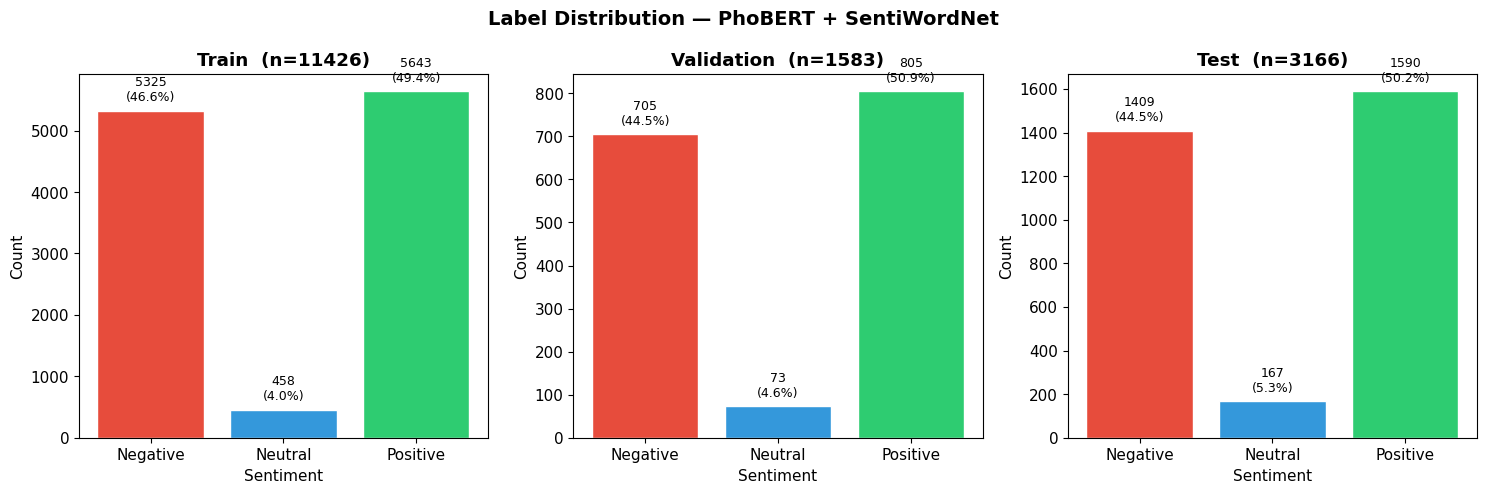

Saved: label_distribution.png


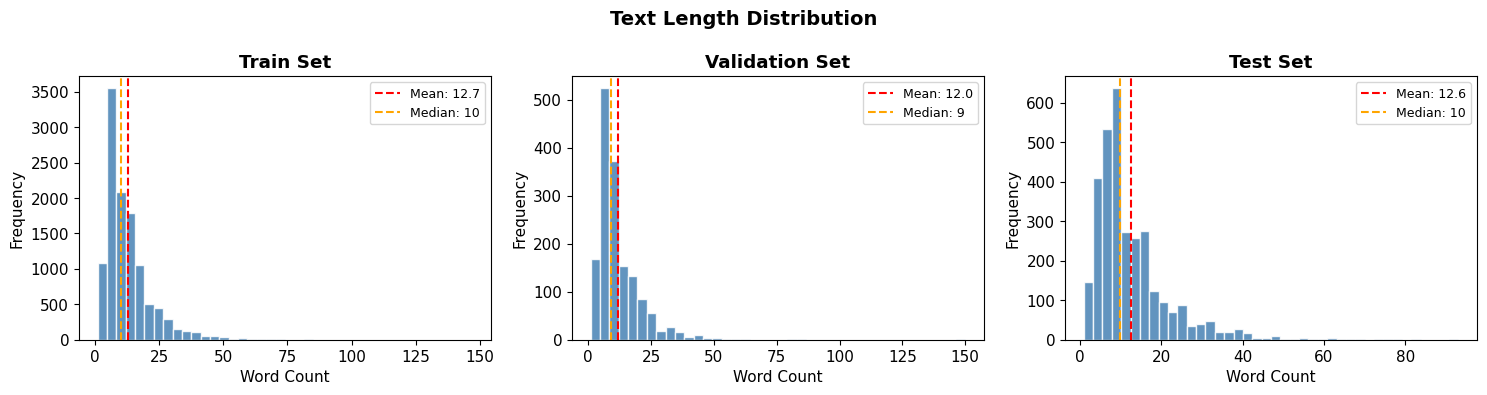

Saved: text_length_distribution.png


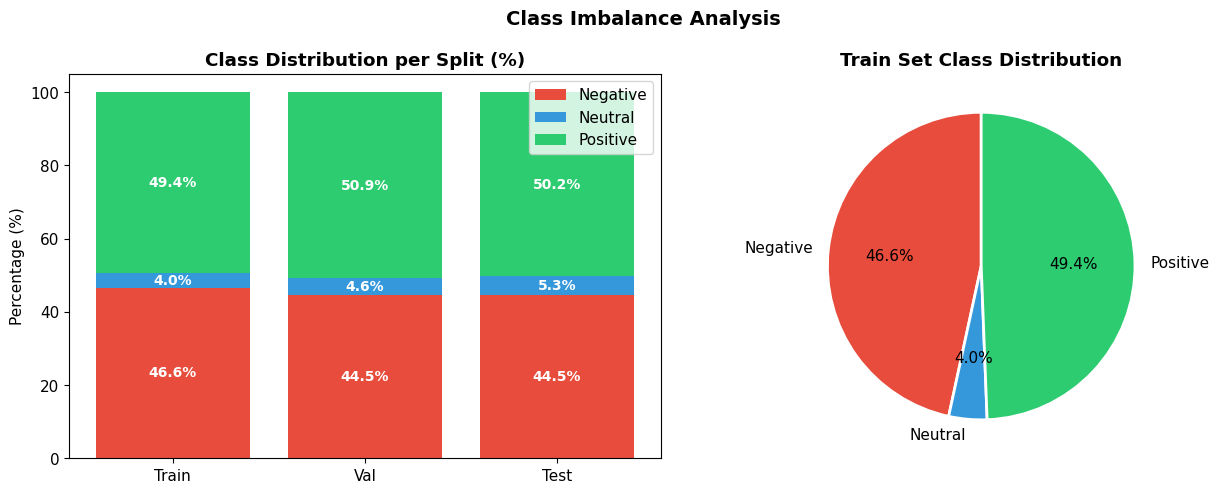

Saved: class_imbalance.png


In [24]:
import matplotlib.pyplot as plt
from collections import Counter
import os

COLORS = ['#e74c3c', '#3498db', '#2ecc71']
plt.rcParams.update({'font.size': 11, 'figure.facecolor': 'white'})

# ── Label Distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, labels) in zip(axes, [('Train', train_labels),
                                       ('Validation', val_labels),
                                       ('Test', test_labels)]):
    counts = Counter(labels)
    cls_names  = [config.LABEL_MAP[i] for i in range(config.NUM_CLASSES)]
    cls_counts = [counts.get(i, 0) for i in range(config.NUM_CLASSES)]
    bars = ax.bar(cls_names, cls_counts, color=COLORS, edgecolor='white')
    for bar, cnt in zip(bars, cls_counts):
        pct = cnt / len(labels) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(cls_counts)*0.02,
                f'{cnt}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{name}  (n={len(labels)})', fontweight='bold')
    ax.set_xlabel('Sentiment')
    ax.set_ylabel('Count')
plt.suptitle('Label Distribution — PhoBERT + SentiWordNet', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'label_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: label_distribution.png')

# ── Text Length Distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, texts) in zip(axes, [('Train', train_texts),
                                      ('Validation', val_texts),
                                      ('Test', test_texts)]):
    lengths = [len(t.split()) for t in texts]
    ax.hist(lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(lengths), color='red', linestyle='--',
               label=f'Mean: {np.mean(lengths):.1f}')
    ax.axvline(np.median(lengths), color='orange', linestyle='--',
               label=f'Median: {np.median(lengths):.0f}')
    ax.set_title(f'{name} Set', fontweight='bold')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
plt.suptitle('Text Length Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'text_length_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: text_length_distribution.png')

# ── Class Imbalance ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
split_dicts  = {'Train': Counter(train_labels),
                'Val':   Counter(val_labels),
                'Test':  Counter(test_labels)}
x_labels = list(split_dicts.keys())
totals   = [sum(v.values()) for v in split_dicts.values()]
bottoms  = np.zeros(len(x_labels))
for cls_idx, cls_name in config.LABEL_MAP.items():
    pcts = [split_dicts[s].get(cls_idx, 0) / t * 100
            for s, t in zip(x_labels, totals)]
    axes[0].bar(x_labels, pcts, bottom=bottoms, label=cls_name,
                color=COLORS[cls_idx])
    for i, (p, b) in enumerate(zip(pcts, bottoms)):
        if p > 3:
            axes[0].text(i, b + p/2, f'{p:.1f}%', ha='center', va='center',
                         color='white', fontweight='bold', fontsize=10)
    bottoms += np.array(pcts)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('Class Distribution per Split (%)', fontweight='bold')
axes[0].legend(loc='upper right')

train_vals = [Counter(train_labels).get(i, 0) for i in range(config.NUM_CLASSES)]
axes[1].pie(train_vals,
            labels=[config.LABEL_MAP[i] for i in range(config.NUM_CLASSES)],
            autopct='%1.1f%%', colors=COLORS, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Train Set Class Distribution', fontweight='bold')
plt.suptitle('Class Imbalance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'class_imbalance.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_imbalance.png')


## 4. Load SentiWordNet

In [ ]:
# Import from centralized data_utils module
from src.data_utils import load_sentiwordnet

word_to_scores = load_sentiwordnet(config.SENTIWORDNET_FILE)
print(f'Loaded {len(word_to_scores)} words')

In [ ]:
# Import from centralized data_utils module
from src.data_utils import (
    get_swn_features, 
    extract_swn_features_batch, 
    get_swn_features_extended,
    extract_swn_features_extended_batch,
    SWN_FEATURE_NAMES,
    SWN_EXTENDED_FEATURE_NAMES
)

# Use extended features (35 features) instead of basic 8 features
USE_EXTENDED_FEATURES = True  # Set to False to use basic 8 features

if USE_EXTENDED_FEATURES:
    print('Extracting Extended SentiWordNet features (35 features) for train set...')
    train_swn = extract_swn_features_extended_batch(train_texts, word_to_scores)
    feature_names = SWN_EXTENDED_FEATURE_NAMES
    print(f'Feature matrix shape: {train_swn.shape}')
    print(f'Using {len(feature_names)} features')
else:
    print('Extracting Basic SentiWordNet features (8 features) for train set...')
    train_swn = extract_swn_features_batch(train_texts, word_to_scores)
    feature_names = SWN_FEATURE_NAMES
    print(f'Feature matrix shape: {train_swn.shape}')

# ── Feature Distribution per Class (show first 8 features) ──────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for feat_idx, (ax, feat_name) in enumerate(zip(axes, feature_names[:8])):
    for cls_idx in range(config.NUM_CLASSES):
        mask = np.array(train_labels) == cls_idx
        ax.hist(train_swn[mask, feat_idx], bins=30, alpha=0.6,
                label=config.LABEL_MAP[cls_idx],
                color=COLORS[cls_idx], edgecolor='none')
    ax.set_title(feat_name, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
plt.suptitle('SentiWordNet Feature Distribution by Class (Train) - First 8 Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'swn_feature_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: swn_feature_distribution.png')

# ── Mean Feature Values per Class (show first 12 features) ────────────────────────────────────────────
n_show = min(12, len(feature_names))
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(n_show)
width = 0.25
for cls_idx in range(config.NUM_CLASSES):
    mask  = np.array(train_labels) == cls_idx
    means = train_swn[mask, :n_show].mean(axis=0)
    ax.bar(x + cls_idx * width, means, width,
           label=config.LABEL_MAP[cls_idx],
           color=COLORS[cls_idx], edgecolor='white')
ax.set_xticks(x + width)
ax.set_xticklabels(feature_names[:n_show], rotation=25, ha='right', fontsize=9)
ax.set_title(f'Mean SentiWordNet Feature Values per Class (Train) - First {n_show} Features', fontweight='bold')
ax.set_ylabel('Mean Value')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'swn_feature_means.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: swn_feature_means.png')

# ── Feature Statistics Summary ─────────────────────────────────────────────────────────────────────
print(f'\nFeature Statistics Summary ({len(feature_names)} features):')
print('=' * 60)
for i, name in enumerate(feature_names):
    mean_val = train_swn[:, i].mean()
    std_val = train_swn[:, i].std()
    min_val = train_swn[:, i].min()
    max_val = train_swn[:, i].max()
    print(f'{name:20s}: mean={mean_val:8.4f}, std={std_val:8.4f}, min={min_val:8.4f}, max={max_val:8.4f}')
print('=' * 60)

print(f'\n✓ All visualizations saved to:\n  {config.VISUALIZATIONS_DIR}')

## 5. PhoBERT Feature Extraction (Fine-tuned Baseline)

In [27]:
# Define PhoBERT Classifier class (same architecture as baseline)
class PhoBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.1):
        super(PhoBERTClassifier, self).__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return logits, pooled_output

    def extract_embeddings(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
            pooled_output = outputs.last_hidden_state[:, 0, :]
        return pooled_output

# Function to safely load model checkpoint
def load_model_safe(model, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    if isinstance(checkpoint, dict):
        if 'state_dict' in checkpoint:
            state_dict = checkpoint['state_dict']
        elif 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint
    else:
        state_dict = checkpoint
    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith('module.'):
            new_state_dict[k[7:]] = v
        else:
            new_state_dict[k] = v
    model.load_state_dict(new_state_dict)
    return model

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
print(f'Tokenizer loaded: {config.MODEL_NAME}')

# Load fine-tuned PhoBERT baseline model
print(f'📥 Loading PhoBERT Baseline model from: {config.PHOBERT_MODEL_DIR}')
phobert_model = PhoBERTClassifier(model_name=config.MODEL_NAME, num_classes=config.NUM_CLASSES)
phobert_model = load_model_safe(phobert_model, config.PHOBERT_MODEL_DIR, config.DEVICE)
phobert_model = phobert_model.to(config.DEVICE)

# Freeze all parameters - only use for feature extraction
for param in phobert_model.parameters():
    param.requires_grad = False
phobert_model.eval()
print(f'✅ PhoBERT model loaded and frozen on {config.DEVICE}')

def extract_phobert_embeddings(texts, batch_size=64):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(config.DEVICE)
        with torch.no_grad():
            embeddings_batch = phobert_model.extract_embeddings(inputs['input_ids'], inputs['attention_mask'])
            embeddings.append(embeddings_batch.cpu().numpy())
        if (i // batch_size + 1) % 10 == 0:
            print(f"  Processed {i + len(batch_texts)}/{len(texts)} samples")
    return np.vstack(embeddings)

print("Extracting PhoBERT embeddings for train set...")
train_phobert = extract_phobert_embeddings(train_texts)
print(f"Train embeddings shape: {train_phobert.shape}")
print("Extracting PhoBERT embeddings for validation set...")
val_phobert = extract_phobert_embeddings(val_texts)
print(f"Val embeddings shape: {val_phobert.shape}")
print("Extracting PhoBERT embeddings for test set...")
test_phobert = extract_phobert_embeddings(test_texts)
print(f"Test embeddings shape: {test_phobert.shape}")

Tokenizer loaded: vinai/phobert-base
📥 Loading PhoBERT Baseline model from: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT/baseline/models/phobert_model.pt


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ PhoBERT model loaded and frozen on cuda
Extracting PhoBERT embeddings for train set...
  Processed 640/11426 samples
  Processed 1280/11426 samples
  Processed 1920/11426 samples
  Processed 2560/11426 samples
  Processed 3200/11426 samples
  Processed 3840/11426 samples
  Processed 4480/11426 samples
  Processed 5120/11426 samples
  Processed 5760/11426 samples
  Processed 6400/11426 samples
  Processed 7040/11426 samples
  Processed 7680/11426 samples
  Processed 8320/11426 samples
  Processed 8960/11426 samples
  Processed 9600/11426 samples
  Processed 10240/11426 samples
  Processed 10880/11426 samples
Train embeddings shape: (11426, 768)
Extracting PhoBERT embeddings for validation set...
  Processed 640/1583 samples
  Processed 1280/1583 samples
Val embeddings shape: (1583, 768)
Extracting PhoBERT embeddings for test set...
  Processed 640/3166 samples
  Processed 1280/3166 samples
  Processed 1920/3166 samples
  Processed 2560/3166 samples
  Processed 3166/3166 samples
Test e

## 6. Combine Features

In [ ]:
from sklearn.preprocessing import StandardScaler
from src.data_utils import (
    extract_swn_features_batch,
    extract_swn_features_extended_batch
)

# Extract SentiWordNet features for validation and test sets
if USE_EXTENDED_FEATURES:
    print("Extracting Extended SentiWordNet features for validation set...")
    val_swn = extract_swn_features_extended_batch(val_texts, word_to_scores)
    print("Extracting Extended SentiWordNet features for test set...")
    test_swn = extract_swn_features_extended_batch(test_texts, word_to_scores)
else:
    print("Extracting Basic SentiWordNet features for validation set...")
    val_swn = extract_swn_features_batch(val_texts, word_to_scores)
    print("Extracting Basic SentiWordNet features for test set...")
    test_swn = extract_swn_features_batch(test_texts, word_to_scores)

print(f"Val SentiWordNet features shape: {val_swn.shape}")
print(f"Test SentiWordNet features shape: {test_swn.shape}")

phobert_scaler = StandardScaler()
swn_scaler = StandardScaler()

train_phobert_scaled = phobert_scaler.fit_transform(train_phobert)
val_phobert_scaled = phobert_scaler.transform(val_phobert)
test_phobert_scaled = phobert_scaler.transform(test_phobert)

train_swn_scaled = swn_scaler.fit_transform(train_swn)
val_swn_scaled = swn_scaler.transform(val_swn)
test_swn_scaled = swn_scaler.transform(test_swn)

def build_feature_sets(alpha):
    return {
        "train": np.hstack([train_phobert_scaled, alpha * train_swn_scaled]),
        "val": np.hstack([val_phobert_scaled, alpha * val_swn_scaled]),
        "test": np.hstack([test_phobert_scaled, alpha * test_swn_scaled]),
    }

feature_sets = {
    "phobert_only": {
        "train": train_phobert_scaled,
        "val": val_phobert_scaled,
        "test": test_phobert_scaled,
    },
    "swn_only": {
        "train": train_swn_scaled,
        "val": val_swn_scaled,
        "test": test_swn_scaled,
    },
}

alpha_grid = [0.25, 0.5, 1.0, 2.0, 4.0]
for alpha in alpha_grid:
    feature_sets[f"hybrid_alpha_{alpha}"] = build_feature_sets(alpha)

print("\nScaled feature shapes:")
print(f"  PhoBERT train: {train_phobert_scaled.shape}")
print(f"  SentiWordNet train: {train_swn_scaled.shape}")
print(f"  Total features per sample: {train_phobert_scaled.shape[1] + train_swn_scaled.shape[1]}")
for name, features in feature_sets.items():
    print(f"  {name}: train={features['train'].shape}, val={features['val'].shape}, test={features['test'].shape}")

## 7. Train Model

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import time
import joblib

C_grid = [0.01, 0.1, 1.0, 5.0, 10.0]
class_weight_grid = [None, "balanced"]

def evaluate_model(model, features, labels):
    y_pred = model.predict(features)
    y_proba = model.predict_proba(features)
    accuracy = accuracy_score(labels, y_pred)
    f1_macro = f1_score(labels, y_pred, average="macro")
    precision_macro = precision_score(labels, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(labels, y_pred, average="macro", zero_division=0)
    f1_per_class = f1_score(labels, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    precision_per_class = precision_score(labels, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    recall_per_class = recall_score(labels, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    cm = confusion_matrix(labels, y_pred, labels=[0, 1, 2])
    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_per_class": f1_per_class.tolist(),
        "precision_per_class": precision_per_class.tolist(),
        "recall_per_class": recall_per_class.tolist(),
        "confusion_matrix": cm.tolist(),
        "y_pred": y_pred.tolist(),
        "y_proba": y_proba.tolist(),
    }

def print_metrics(result, split_name):
    print(f"\n{'=' * 50}")
    print(f"{split_name} Results:")
    print(f"{'=' * 50}")
    print(f"Accuracy:  {result['accuracy']:.4f}")
    print(f"F1 (macro): {result['f1_macro']:.4f}")
    print(f"Precision (macro): {result['precision_macro']:.4f}")
    print(f"Recall (macro): {result['recall_macro']:.4f}")
    print("\nPer-Class Metrics:")
    for i, name in config.LABEL_MAP.items():
        print(
            f"  {name}: P={result['precision_per_class'][i]:.4f}, "
            f"R={result['recall_per_class'][i]:.4f}, F1={result['f1_per_class'][i]:.4f}"
        )
    print("\nConfusion Matrix:")
    print(np.array(result["confusion_matrix"]))

def train_and_score(feature_name, features, C, class_weight):
    model = LogisticRegression(
        max_iter=3000,
        C=C,
        class_weight=class_weight,
        solver="lbfgs",
        multi_class="auto",
        random_state=42,
        n_jobs=-1,
    )
    start = time.time()
    model.fit(features["train"], train_labels)
    train_seconds = time.time() - start
    train_result = evaluate_model(model, features["train"], train_labels)
    val_result = evaluate_model(model, features["val"], val_labels)
    test_result = evaluate_model(model, features["test"], test_labels)
    return {
        "feature_name": feature_name,
        "C": C,
        "class_weight": class_weight,
        "model": model,
        "train_seconds": train_seconds,
        "train": train_result,
        "val": val_result,
        "test": test_result,
    }

search_results = []
best_run = None

print("Running validation search for PhoBERT-only and PhoBERT+SentiWordNet...")
for feature_name, features in feature_sets.items():
    if feature_name == "swn_only":
        continue
    print(f"\nEvaluating feature set: {feature_name}")
    for C in C_grid:
        for class_weight in class_weight_grid:
            run = train_and_score(feature_name, features, C, class_weight)
            search_results.append(run)
            print(
                f"  C={C:<4} class_weight={str(class_weight):<8} "
                f"val_f1={run['val']['f1_macro']:.4f} test_f1={run['test']['f1_macro']:.4f}"
            )
            if best_run is None or run["val"]["f1_macro"] > best_run["val"]["f1_macro"]:
                best_run = run

baseline_run = max(
    (run for run in search_results if run["feature_name"] == "phobert_only"),
    key=lambda run: run["val"]["f1_macro"],
)

best_hybrid_run = None
hybrid_candidates = [run for run in search_results if run["feature_name"].startswith("hybrid_alpha_")]
if hybrid_candidates:
    best_hybrid_run = max(hybrid_candidates, key=lambda run: run["val"]["f1_macro"])

late_fusion_run = None
late_fusion_weights = [0.7, 0.8, 0.9]

if best_hybrid_run is None or best_hybrid_run["val"]["f1_macro"] <= baseline_run["val"]["f1_macro"]:
    print("\nHybrid did not beat PhoBERT-only on validation. Running late fusion fallback...")
    swn_candidates = []
    for C in C_grid:
        for class_weight in class_weight_grid:
            run = train_and_score("swn_only", feature_sets["swn_only"], C, class_weight)
            swn_candidates.append(run)
            print(
                f"  SWN-only C={C:<4} class_weight={str(class_weight):<8} "
                f"val_f1={run['val']['f1_macro']:.4f}"
            )
    best_swn_run = max(swn_candidates, key=lambda run: run["val"]["f1_macro"])

    def blend_probabilities(weight, left, right):
        return weight * np.array(left) + (1 - weight) * np.array(right)

    def evaluate_probs(proba, labels):
        preds = np.argmax(proba, axis=1)
        accuracy = accuracy_score(labels, preds)
        f1_macro = f1_score(labels, preds, average="macro")
        precision_macro = precision_score(labels, preds, average="macro", zero_division=0)
        recall_macro = recall_score(labels, preds, average="macro", zero_division=0)
        f1_per_class = f1_score(labels, preds, average=None, labels=[0, 1, 2], zero_division=0)
        precision_per_class = precision_score(labels, preds, average=None, labels=[0, 1, 2], zero_division=0)
        recall_per_class = recall_score(labels, preds, average=None, labels=[0, 1, 2], zero_division=0)
        cm = confusion_matrix(labels, preds, labels=[0, 1, 2])
        return {
            "accuracy": accuracy,
            "f1_macro": f1_macro,
            "precision_macro": precision_macro,
            "recall_macro": recall_macro,
            "f1_per_class": f1_per_class.tolist(),
            "precision_per_class": precision_per_class.tolist(),
            "recall_per_class": recall_per_class.tolist(),
            "confusion_matrix": cm.tolist(),
            "y_pred": preds.tolist(),
            "y_proba": proba.tolist(),
        }

    for weight in late_fusion_weights:
        val_proba = blend_probabilities(weight, baseline_run["val"]["y_proba"], best_swn_run["val"]["y_proba"])
        test_proba = blend_probabilities(weight, baseline_run["test"]["y_proba"], best_swn_run["test"]["y_proba"])
        train_proba = blend_probabilities(weight, baseline_run["train"]["y_proba"], best_swn_run["train"]["y_proba"])
        candidate = {
            "feature_name": "late_fusion",
            "fusion_weight_phobert": weight,
            "model": {
                "phobert_only": baseline_run["model"],
                "swn_only": best_swn_run["model"],
            },
            "train_seconds": baseline_run["train_seconds"] + best_swn_run["train_seconds"],
            "train": evaluate_probs(train_proba, train_labels),
            "val": evaluate_probs(val_proba, val_labels),
            "test": evaluate_probs(test_proba, test_labels),
            "C": baseline_run["C"],
            "class_weight": baseline_run["class_weight"],
            "swn_C": best_swn_run["C"],
            "swn_class_weight": best_swn_run["class_weight"],
        }
        print(
            f"  Late fusion w={weight:.2f} "
            f"val_f1={candidate['val']['f1_macro']:.4f} test_f1={candidate['test']['f1_macro']:.4f}"
        )
        if late_fusion_run is None or candidate["val"]["f1_macro"] > late_fusion_run["val"]["f1_macro"]:
            late_fusion_run = candidate

if late_fusion_run is not None and late_fusion_run["val"]["f1_macro"] > best_run["val"]["f1_macro"]:
    best_run = late_fusion_run

selected_feature_name = best_run["feature_name"]
selected_alpha = None
if selected_feature_name.startswith("hybrid_alpha_"):
    selected_alpha = float(selected_feature_name.split("_")[-1])

if selected_feature_name == "late_fusion":
    selected_features = None
else:
    selected_features = feature_sets[selected_feature_name]

model = best_run["model"]
results = {
    "train": best_run["train"],
    "val": best_run["val"],
    "test": best_run["test"],
}
train_time = best_run["train_seconds"]
model_selection_summary = {
    "selected_feature_name": selected_feature_name,
    "selected_alpha": selected_alpha,
    "selected_C": best_run.get("C"),
    "selected_class_weight": best_run.get("class_weight"),
    "late_fusion_weight_phobert": best_run.get("fusion_weight_phobert"),
    "baseline_val_f1": baseline_run["val"]["f1_macro"],
    "best_hybrid_val_f1": best_hybrid_run["val"]["f1_macro"] if best_hybrid_run is not None else None,
    "selected_val_f1": best_run["val"]["f1_macro"],
}

print("\nSelected configuration:")
print(model_selection_summary)
print_metrics(results["train"], "Train")
print_metrics(results["val"], "Validation")
print_metrics(results["test"], "Test")

model_path = f"{config.MODELS_DIR}/phobert_swn_baseline_model.pkl"
joblib.dump(best_run, model_path)
print(f"Best run saved to: {model_path}")


Running validation search for PhoBERT-only and PhoBERT+SentiWordNet...

Evaluating feature set: phobert_only


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  C=0.01 class_weight=None     val_f1=0.8553 test_f1=0.8253


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  C=0.01 class_weight=balanced val_f1=0.8419 test_f1=0.8233


...

  C=5.0  class_weight=balanced val_f1=0.8512 test_f1=0.8145


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  C=10.0 class_weight=None     val_f1=0.8511 test_f1=0.8150


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  C=10.0 class_weight=balanced val_f1=0.8406 test_f1=0.8130

Selected configuration:
{'selected_feature_name': 'hybrid_alpha_0.5', 'selected_alpha': 0.5, 'selected_C': 0.1, 'selected_class_weight': None, 'late_fusion_weight_phobert': None, 'baseline_val_f1': 0.8576036942612091, 'best_hybrid_val_f1': 0.8598443709375014, 'selected_val_f1': 0.8598443709375014}

Train Results:
Accuracy:  0.9961
F1 (macro): 0.9929
Precision (macro): 0.9959
Recall (macro): 0.9900

Per-Class Metrics:
  Negative: P=0.9949, R=0.9987, F1=0.9968
  Neutral: P=0.9955, R=0.9760, F1=0.9857
  Positive: P=0.9972, R=0.9952, F1=0.9962

Confusion Matrix:
[[5318    0    7]
 [   2  447    9]
 [  25    2 5616]]

Validation Results:
Accuracy:  0.9463
F1 (macro): 0.8598
Precision (macro): 0.8751
Recall (macro): 0.8471

Per-Class Metrics:
  Negative: P=0.9471, R=0.9645, F1=0.9557
  Neutral: P=0.7143, R=0.6164, F1=0.6618
  Positive: P=0.9638, R=0.9602, F1=0.9620

Confusion Matrix:
[[680  10  15]
 [ 14  45  14]
 [ 24   8 773]]

T

## 8. Evaluation

In [30]:
print("Validation model selection completed.")
print(f"Selected feature set: {model_selection_summary['selected_feature_name']}")
print(f"Selected C: {model_selection_summary['selected_C']}")
print(f"Selected class_weight: {model_selection_summary['selected_class_weight']}")
if model_selection_summary["selected_alpha"] is not None:
    print(f"Selected alpha: {model_selection_summary['selected_alpha']}")
if model_selection_summary["late_fusion_weight_phobert"] is not None:
    print(f"Late fusion weight (PhoBERT): {model_selection_summary['late_fusion_weight_phobert']}")


Validation model selection completed.
Selected feature set: hybrid_alpha_0.5
Selected C: 0.1
Selected class_weight: None
Selected alpha: 0.5


## 9. Visualizations

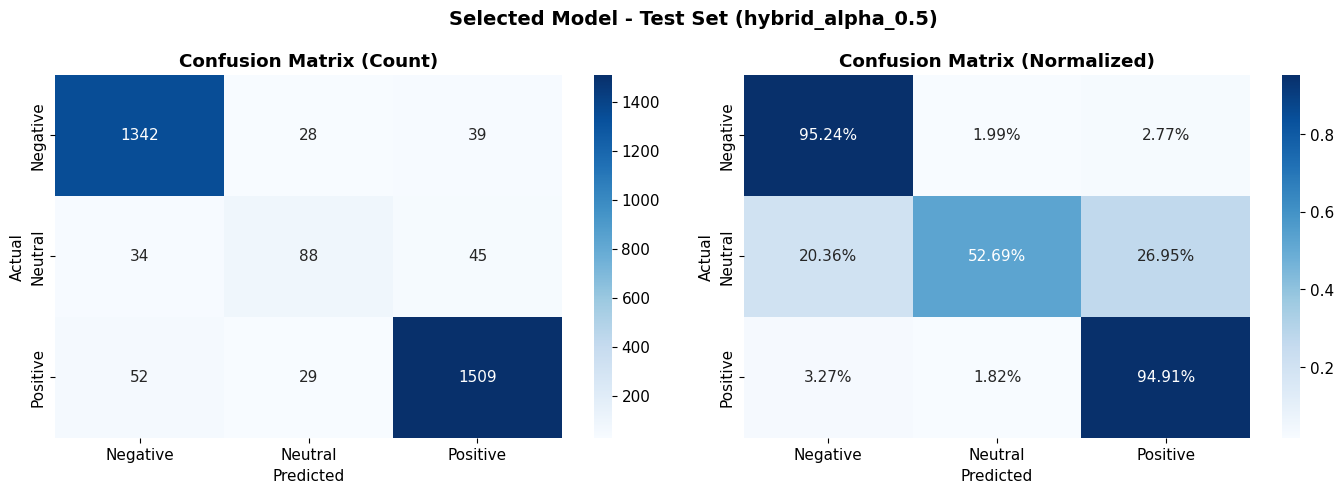

Saved: confusion_matrix.png


In [31]:
import seaborn as sns

y_test_pred = np.array(results["test"]["y_pred"])
cm = np.array(results["test"]["confusion_matrix"])
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=config.LABEL_MAP.values(), yticklabels=config.LABEL_MAP.values(), ax=axes[0])
axes[0].set_title("Confusion Matrix (Count)", fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", xticklabels=config.LABEL_MAP.values(), yticklabels=config.LABEL_MAP.values(), ax=axes[1])
axes[1].set_title("Confusion Matrix (Normalized)", fontweight="bold")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
plt.suptitle(f"Selected Model - Test Set ({selected_feature_name})", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{config.VISUALIZATIONS_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")


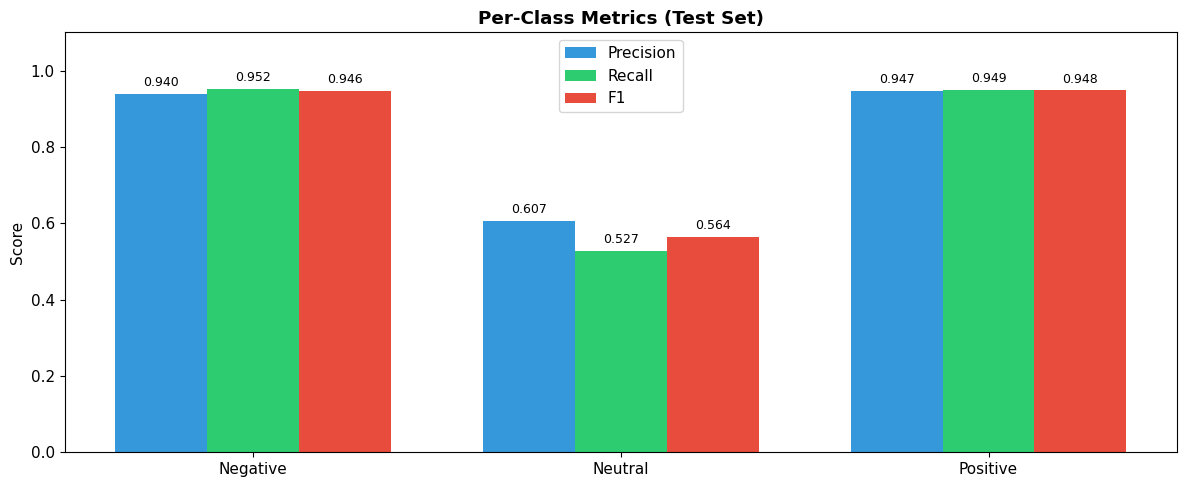

Saved: per_class_metrics.png


In [32]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(config.NUM_CLASSES)
width = 0.25
test_results = results["test"]
precision = test_results["precision_per_class"]
recall = test_results["recall_per_class"]
f1 = test_results["f1_per_class"]
ax.bar(x - width, precision, width, label="Precision", color="#3498db")
ax.bar(x, recall, width, label="Recall", color="#2ecc71")
ax.bar(x + width, f1, width, label="F1", color="#e74c3c")
ax.set_xticks(x)
ax.set_xticklabels(config.LABEL_MAP.values())
ax.set_ylabel("Score")
ax.set_title("Per-Class Metrics (Test Set)", fontweight="bold")
ax.legend()
ax.set_ylim([0, 1.1])
for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    ax.text(i - width, p + 0.02, f"{p:.3f}", ha="center", fontsize=9)
    ax.text(i, r + 0.02, f"{r:.3f}", ha="center", fontsize=9)
    ax.text(i + width, f + 0.02, f"{f:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{config.VISUALIZATIONS_DIR}/per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: per_class_metrics.png")

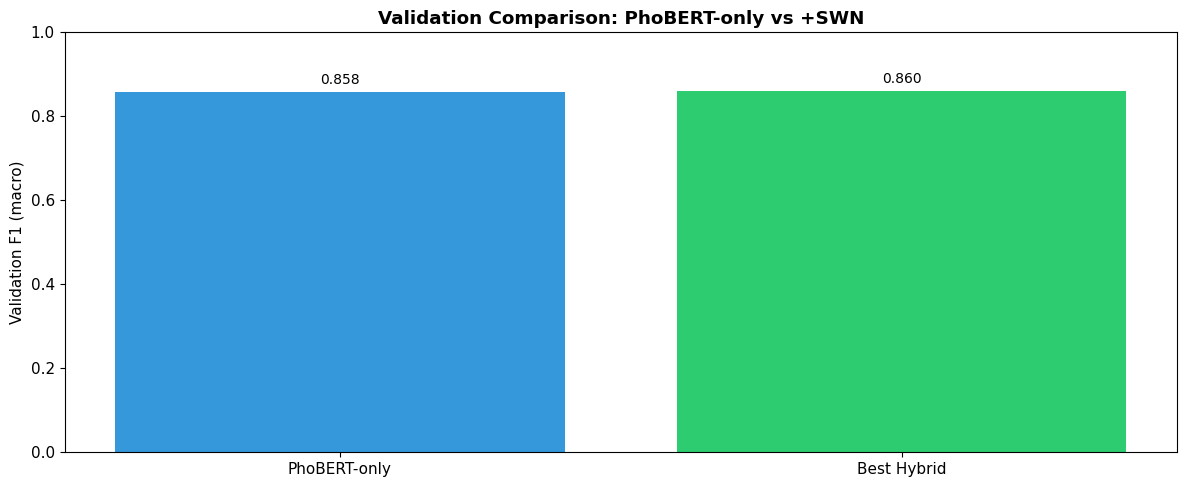

Saved: performance_comparison.png


In [33]:
fig, ax = plt.subplots(figsize=(12, 5))

comparison_names = ["PhoBERT-only", "Best Hybrid"]
comparison_vals = [baseline_run["val"]["f1_macro"]]

if best_hybrid_run is not None:
    comparison_vals.append(best_hybrid_run["val"]["f1_macro"])
else:
    comparison_vals.append(np.nan)

if late_fusion_run is not None:
    comparison_names.append("Late Fusion")
    comparison_vals.append(late_fusion_run["val"]["f1_macro"])

colors = ["#3498db", "#2ecc71", "#9b59b6"][:len(comparison_names)]
bars = ax.bar(comparison_names, comparison_vals, color=colors)
ax.set_ylabel("Validation F1 (macro)")
ax.set_title("Validation Comparison: PhoBERT-only vs +SWN", fontweight="bold")
ax.set_ylim([0, 1.0])
for bar, val in zip(bars, comparison_vals):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(f"{config.VISUALIZATIONS_DIR}/performance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: performance_comparison.png")


## 10. Save Summary

In [34]:
import pandas as pd

summary_data = []
for split in ["train", "val", "test"]:
    r = results[split]
    summary_data.append({
        "Split": split.capitalize(),
        "Selected_Features": selected_feature_name,
        "Alpha": selected_alpha,
        "C": model_selection_summary["selected_C"],
        "Class_Weight": model_selection_summary["selected_class_weight"],
        "Late_Fusion_Weight_PhoBERT": model_selection_summary["late_fusion_weight_phobert"],
        "Accuracy": r["accuracy"],
        "F1_Macro": r["f1_macro"],
        "Precision_Macro": r["precision_macro"],
        "Recall_Macro": r["recall_macro"],
        "F1_Negative": r["f1_per_class"][0],
        "F1_Neutral": r["f1_per_class"][1],
        "F1_Positive": r["f1_per_class"][2],
    })

df_summary = pd.DataFrame(summary_data)
summary_path = f"{config.SUMMARIES_DIR}/summary.csv"
df_summary.to_csv(summary_path, index=False)
print(f"Summary saved to: {summary_path}")
print("\nResults Summary:")
print(df_summary.to_string(index=False))


Summary saved to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet/baseline/summaries/summary.csv

Results Summary:
Split Selected_Features  Alpha   C Class_Weight Late_Fusion_Weight_PhoBERT  Accuracy  F1_Macro  Precision_Macro  Recall_Macro  F1_Negative  F1_Neutral  F1_Positive
Train  hybrid_alpha_0.5    0.5 0.1         None                       None  0.996062  0.992889         0.995884      0.989961     0.996813    0.985667     0.996186
  Val  hybrid_alpha_0.5    0.5 0.1         None                       None  0.946304  0.859844         0.875067      0.847075     0.955727    0.661765     0.962041
 Test  hybrid_alpha_0.5    0.5 0.1         None                       None  0.928301  0.819445         0.831314      0.809484     0.946070    0.564103     0.948162


In [ ]:
from datetime import datetime

training_log_path = f"{config.SUMMARIES_DIR}/training_results.txt"
with open(training_log_path, "w", encoding="utf-8") as f:
    f.write("=" * 50 + "\n")
    f.write("TRAINING RESULTS - PhoBERT + SentiWordNet Baseline\n")
    f.write("=" * 50 + "\n")
    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("Model Type: PhoBERT_Sentiwordnet\n")
    f.write("Experiment: baseline\n")
    f.write("\n" + "-" * 50 + "\n")
    f.write("MODEL SELECTION\n")
    f.write("-" * 50 + "\n")
    f.write(f"Selected Features: {selected_feature_name}\n")
    f.write(f"Selected Alpha: {selected_alpha}\n")
    f.write(f"Selected C: {model_selection_summary['selected_C']}\n")
    f.write(f"Selected Class Weight: {model_selection_summary['selected_class_weight']}\n")
    f.write(f"Late Fusion Weight (PhoBERT): {model_selection_summary['late_fusion_weight_phobert']}\n")
    f.write(f"PhoBERT-only Val F1: {baseline_run['val']['f1_macro']:.4f}\n")
    if best_hybrid_run is not None:
        f.write(f"Best Hybrid Val F1: {best_hybrid_run['val']['f1_macro']:.4f}\n")
    if late_fusion_run is not None:
        f.write(f"Late Fusion Val F1: {late_fusion_run['val']['f1_macro']:.4f}\n")
    f.write("\n" + "-" * 50 + "\n")
    f.write("FEATURES\n")
    f.write("-" * 50 + "\n")
    f.write(f"PhoBERT Model: Fine-tuned baseline from {config.PHOBERT_MODEL_DIR}\n")
    f.write("PhoBERT Frozen: Yes\n")
    f.write(f"PhoBERT Embeddings: {train_phobert.shape[1]}\n")
    f.write(f"SentiWordNet Features: {train_swn.shape[1]}\n")
    f.write(f"SentiWordNet Feature Type: {'Extended (35 features)' if USE_EXTENDED_FEATURES else 'Basic (8 features)'}\n")
    f.write(f"SentiWordNet Words: {len(word_to_scores)}\n")
    f.write(f"Total Hybrid Features: {train_phobert.shape[1] + train_swn.shape[1]}\n")
    f.write("\n" + "-" * 50 + "\n")
    f.write("TEST RESULTS\n")
    f.write("-" * 50 + "\n")
    r_test = results["test"]
    f.write(f"Test Accuracy: {r_test['accuracy']:.4f}\n")
    f.write(f"Test F1 (macro): {r_test['f1_macro']:.4f}\n")
    f.write(f"Test Precision (macro): {r_test['precision_macro']:.4f}\n")
    f.write(f"Test Recall (macro): {r_test['recall_macro']:.4f}\n")
    f.write("\nPer-Class Metrics:\n")
    for i, name in config.LABEL_MAP.items():
        f.write(
            f"  {name}: Precision={r_test['precision_per_class'][i]:.4f}, "
            f"Recall={r_test['recall_per_class'][i]:.4f}, F1={r_test['f1_per_class'][i]:.4f}\n"
        )
    f.write("\n" + "-" * 50 + "\n")
    f.write("CONFUSION MATRIX (Test)\n")
    f.write("-" * 50 + "\n")
    for row in r_test["confusion_matrix"]:
        f.write(f"[{row[0]:4d} {row[1]:4d} {row[2]:4d}]\n")
    f.write("\n" + "-" * 50 + "\n")
    f.write("TRAINING TIME\n")
    f.write("-" * 50 + "\n")
    f.write(f"Total Time: {train_time:.1f} seconds ({train_time / 60:.1f} minutes)\n")
    f.write(f"Training Samples: {len(train_labels)}\n")

print(f"Training log saved to: {training_log_path}")

## 11. Final Summary

In [36]:
print("\n" + "=" * 60)
print("PHOBERT + SENTIWORDNET BASELINE - COMPLETE SUMMARY")
print("=" * 60)
print("\nSelection:")
print(f"  - Selected features: {selected_feature_name}")
print(f"  - Selected C: {model_selection_summary['selected_C']}")
print(f"  - Selected class_weight: {model_selection_summary['selected_class_weight']}")
if selected_alpha is not None:
    print(f"  - Selected alpha: {selected_alpha}")
if model_selection_summary["late_fusion_weight_phobert"] is not None:
    print(f"  - Late fusion weight (PhoBERT): {model_selection_summary['late_fusion_weight_phobert']}")

print("\nValidation comparison:")
print(f"  - PhoBERT-only: {baseline_run['val']['f1_macro']:.4f}")
if best_hybrid_run is not None:
    print(f"  - Best hybrid: {best_hybrid_run['val']['f1_macro']:.4f}")
if late_fusion_run is not None:
    print(f"  - Late fusion: {late_fusion_run['val']['f1_macro']:.4f}")

print("\nTest Results:")
r_test = results["test"]
print(f"  - Accuracy: {r_test['accuracy']:.4f}")
print(f"  - F1 (macro): {r_test['f1_macro']:.4f}")
print("\nPer-Class F1 Scores:")
for i, name in config.LABEL_MAP.items():
    print(f"  - {name}: {r_test['f1_per_class'][i]:.4f}")

print("\nFiles saved:")
print(f"  - Model: {config.MODELS_DIR}/phobert_swn_baseline_model.pkl")
print(f"  - Summary CSV: {config.SUMMARIES_DIR}/summary.csv")
print(f"  - Training Log: {config.SUMMARIES_DIR}/training_results.txt")
print(f"  - Visualizations: {config.VISUALIZATIONS_DIR}/")
print("\n" + "=" * 60)



PHOBERT + SENTIWORDNET BASELINE - COMPLETE SUMMARY

Selection:
  - Selected features: hybrid_alpha_0.5
  - Selected C: 0.1
  - Selected class_weight: None
  - Selected alpha: 0.5

Validation comparison:
  - PhoBERT-only: 0.8576
  - Best hybrid: 0.8598

Test Results:
  - Accuracy: 0.9283
  - F1 (macro): 0.8194

Per-Class F1 Scores:
  - Negative: 0.9461
  - Neutral: 0.5641
  - Positive: 0.9482

Files saved:
  - Model: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet/baseline/models/phobert_swn_baseline_model.pkl
  - Summary CSV: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet/baseline/summaries/summary.csv
  - Training Log: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet/baseline/summaries/training_results.txt
  - Visualizations: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet/baseline/visualizations/

